# The purpose of this notebook is to test my new diffusion maps code in the kernel embeddings DA framework.

In [1]:
import numpy as np 
import DAPyr as dap
import matplotlib.pyplot as plt
from importlib import reload
from scipy.io import loadmat
from scipy.sparse.linalg import eigsh

reload(dap)

np.set_printoptions(suppress=True)


In [53]:
uoep = {'mu': 0, 'sigma': 1}
poep = {'mu': 0, 'sigma': 1} 
# original experiments were gamma = 0.2!
uoep_cauchy = {'x0': 0, 'gamma': 0.2}
poep_cauchy = {'x0': 0, 'gamma': 0.2} 

uoep_logistic = {'x0': 0, 'scale' : 1}
poep_logistic = {'x0': 0, 'scale' : 1} 

uoep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1.0, 'threshold': 0}
poep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1.0, 'threshold': 0}


In [54]:
e_name = 'L96: Gaussian'
print(f'starting experiment {e_name}')
bw = 0.5
knn = 0.1
# original experiments!
#bw = 0.02
#knn = 0.1
klb=0.0
e_gaussian = dap.Expt(e_name, {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 1,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_sd,
                       'prescribed_obs_err_params': poep,
                       'save_keest_pab':1,
                       'Ne':80,
                       'T': 401,
                       'T_train': 400,
                       'nle_type': 5,
                       'nle_every': 50, 
                       'Neig': 100,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})

starting experiment L96: Gaussian


## Here's what our original code has been doing (this is the state-dependent Gaussian problem)

DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400
0.5
0.5


<Axes: title={'center': 'Conditional Distribution Estimates for Experiment L96: Gaussian'}, xlabel='$y$', ylabel='$p(y | x)$'>

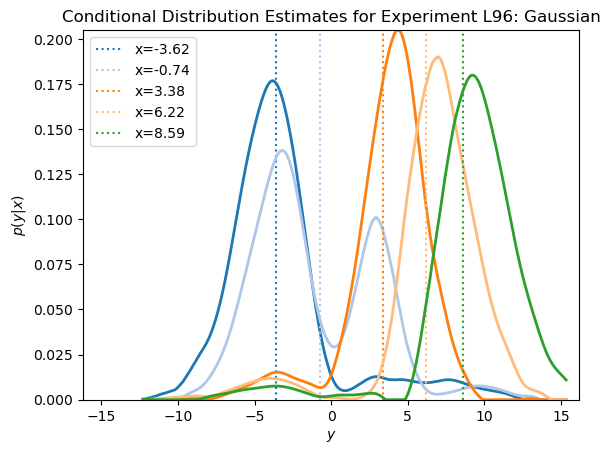

<Figure size 640x480 with 0 Axes>

In [55]:
dap.runDA(e_gaussian)
dap.plot_pab(e_gaussian, plot_states=True)

## Here's what my new code does. It still works, but worse.

DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400


<Axes: title={'center': 'Conditional Distribution Estimates for Experiment L96: Gaussian'}, xlabel='$y$', ylabel='$p(y | x)$'>

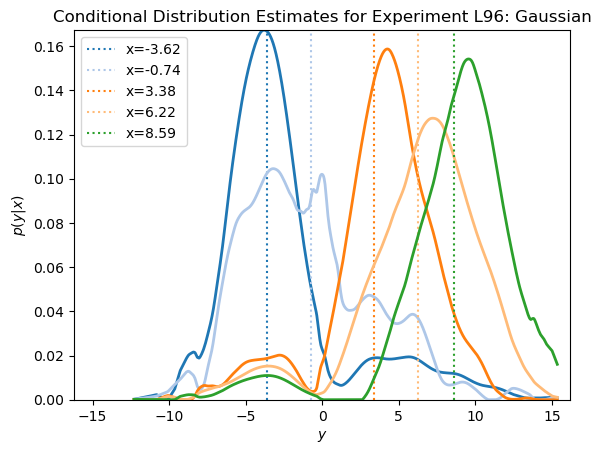

<Figure size 640x480 with 0 Axes>

In [283]:
dap.runDA(e_gaussian)
dap.plot_pab(e_gaussian, plot_states=True)

## And finally, I found by accident that if you symmetrize the row-normalized jump probability matrix after computing it, you get... better results again? This mathematically makes no sense to me, becuase I don't understand what meaning the resulting matrix has. 

DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400


<Axes: title={'center': 'Conditional Distribution Estimates for Experiment L96: Gaussian'}, xlabel='$y$', ylabel='$p(y | x)$'>

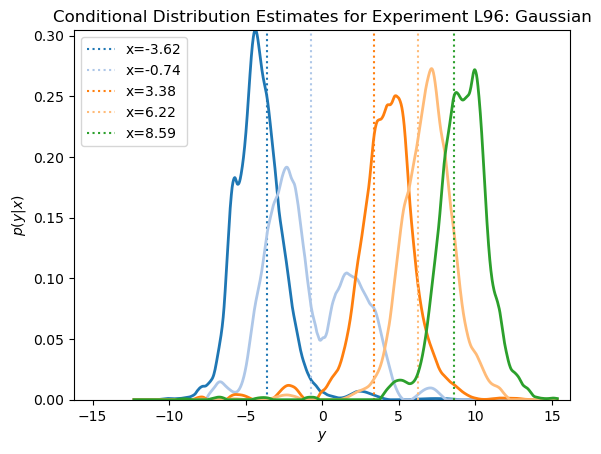

<Figure size 640x480 with 0 Axes>

In [287]:
dap.runDA(e_gaussian)
dap.plot_pab(e_gaussian, plot_states=True)

## Finally, with feature normalization turned on:

DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400


<Axes: title={'center': 'Conditional Distribution Estimates for Experiment L96: Gaussian'}, xlabel='$y$', ylabel='$p(y | x)$'>

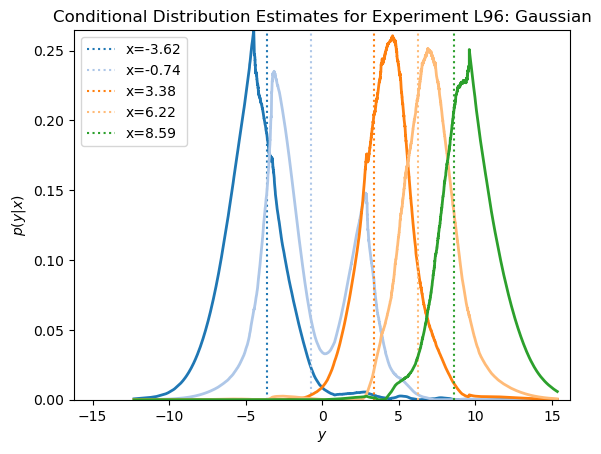

<Figure size 640x480 with 0 Axes>

In [294]:
dap.runDA(e_gaussian)
dap.plot_pab(e_gaussian, plot_states=True)